# Что делает трек хитом? Анализ топ-треков Spotify 2023

Анализ очищенного датасета [Most Streamed Spotify Songs 2023](https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023).
Очистка и подготовка данных - в `data/raw.ipynb`, здесь работаем с готовым `spotify-2023-clean.csv`.

**План:**
1. Импорт библиотек
2. Загрузка очищенных данных
3. Гипотеза 1: мажор слушают охотнее минора (t-тест)
4. Гипотеза 2: плейлисты связаны со стримами сильнее любой аудио-характеристики (корреляция)
5. Гипотеза 3: у релизов есть сезонность
6. Гипотеза 4: больше соавторов -> выше шанс попасть в чарты
7. Продвинутая часть: тренд и сезонность временного ряда релизов (декомпозиция)
8. Выводы

## 1. Импорт библиотек

In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")  # технические предупреждения библиотек не засоряют вывод
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Загрузка очищенных данных

In [2]:
df = pd.read_csv("../data/spotify-2023-clean.csv", parse_dates=["release_date"])
print("размер:", df.shape)
df.head()

размер: (948, 28)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date,track_age_years,total_playlists,chart_platforms
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,89,83,31,0,8,4,2023-07-14,0,641,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,61,74,7,0,10,4,2023-03-23,0,1580,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,32,53,17,0,31,6,2023-06-30,0,1582,4
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,58,72,11,0,11,15,2019-08-23,4,8099,4
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,23,80,14,63,11,6,2023-05-18,0,3304,4


In [3]:
audio_features = [
    "bpm", "danceability_%", "valence_%", "energy_%",
    "acousticness_%", "instrumentalness_%", "liveness_%", "speechiness_%",
]

df[["streams", "total_playlists", "chart_platforms", "artist_count"] + audio_features].describe().round(1)

,streams,total_playlists,chart_platforms,artist_count,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000
mean,"514,017,927.500","5,659.900",2.500,1.600,122.500,67.000,51.400,64.300,27.200,1.600,18.200,10.200
std,"567,927,731.800","8,934.600",1.300,0.900,28.000,14.600,23.500,16.600,26.000,8.400,13.700,9.900
min,"2,762.000",34.000,0.000,1.000,65.000,23.000,4.000,9.000,0.000,0.000,3.000,2.000
25%,"141,143,862.000",914.500,1.000,1.000,99.000,57.000,32.000,53.000,6.000,0.000,10.000,4.000
50%,"287,690,252.000","2,306.000",3.000,1.000,120.500,69.000,51.000,66.000,18.000,0.000,12.000,6.000
75%,"672,942,469.000","5,791.800",4.000,2.000,140.000,78.000,70.000,77.000,43.000,0.000,23.200,11.000
max,"3,703,895,074.000","62,623.000",4.000,8.000,206.000,96.000,97.000,97.000,97.000,91.000,97.000,64.000


## 3. Гипотеза 1: треки в мажоре набирают больше стримов, чем в миноре

Сравниваем распределение `streams` у мажорных и минорных треков. Так как стримы сильно скошены
вправо, рядом с t-тестом Уэлча (сравнение средних) считаем и непараметрический тест Манна-Уитни
(сравнение распределений), чтобы вывод не держался на одних выбросах.

In [4]:
major = df.loc[df["mode"] == "Major", "streams"]
minor = df.loc[df["mode"] == "Minor", "streams"]

print(f"Major: n={len(major)}, среднее={major.mean():,.0f}, медиана={major.median():,.0f}")
print(f"Minor: n={len(minor)}, среднее={minor.mean():,.0f}, медиана={minor.median():,.0f}")
print()

t_stat, t_p = stats.ttest_ind(major, minor, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(major, minor, alternative="two-sided")
print(f"t-тест Уэлча:   t={t_stat:.3f}, p-value={t_p:.3f}")
print(f"Манна-Уитни:    U={u_stat:,.0f}, p-value={u_p:.3f}")

Major: n=546, среднее=535,123,196, медиана=301,494,871
Minor: n=402, среднее=485,352,564, медиана=272,691,474

t-тест Уэлча:   t=1.344, p-value=0.179
Манна-Уитни:    U=116,532, p-value=0.103


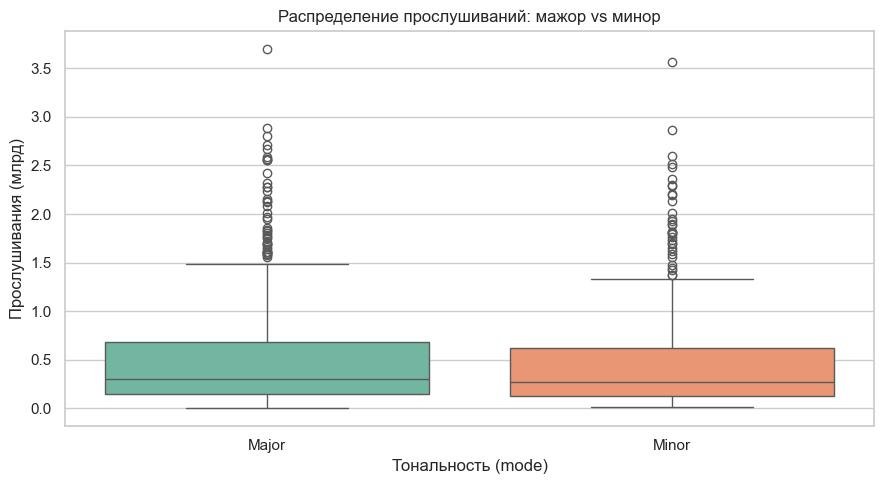

In [5]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="mode", y="streams", hue="mode", palette="Set2", legend=False, ax=ax)
ax.set_title("Распределение прослушиваний: мажор vs минор")
ax.set_xlabel("Тональность (mode)")
ax.set_ylabel("Прослушивания (млрд)")
ax.yaxis.set_major_formatter(lambda x, _: f"{x / 1e9:.1f}")
plt.tight_layout()
plt.show()

**Вывод по Г1.** t-тест Уэлча дал p=0.18, Манн-Уитни p=0.10 - оба выше порога 0.05, разница в прослушиваниях между мажором и минором статистически не значима. Гипотеза не подтверждается: тональность сама по себе не делает трек популярнее.

## 4. Гипотеза 2: число плейлистов связано со стримами сильнее любой аудио-характеристики

Считаем корреляцию `streams` с `total_playlists` и с каждой звуковой характеристикой.
Берём корреляцию Спирмена (ранговую): она устойчива к скошенности стримов и улавливает
монотонную, не обязательно линейную связь.

In [6]:
predictors = ["total_playlists"] + audio_features
corr = (
    df[predictors + ["streams"]]
    .corr(method="spearman")["streams"]
    .drop("streams")
    .sort_values(key=abs, ascending=False)
)
corr.to_frame("corr_with_streams").round(3)

,corr_with_streams
total_playlists,0.834
speechiness_%,-0.108
danceability_%,-0.082
liveness_%,-0.063
acousticness_%,-0.059
valence_%,-0.039
energy_%,-0.033
instrumentalness_%,-0.004
bpm,0.003


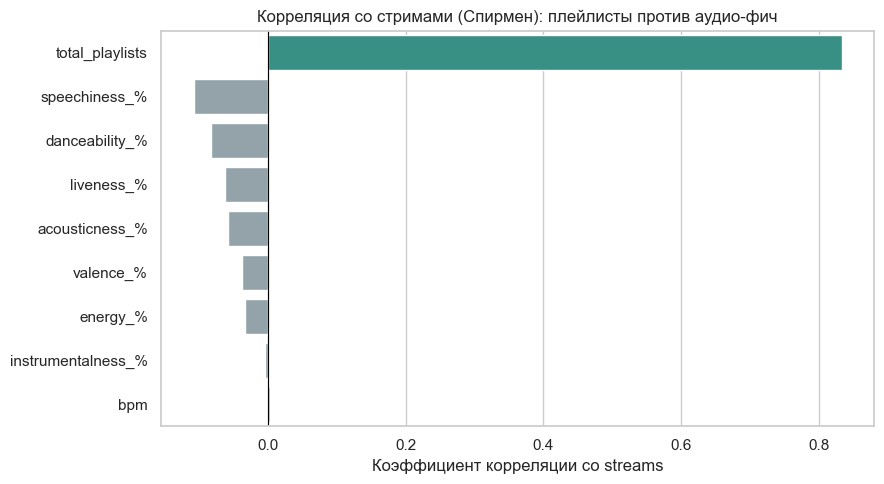

In [7]:
fig, ax = plt.subplots()
colors = ["#2a9d8f" if i == "total_playlists" else "#90a4ae" for i in corr.index]
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette=colors, legend=False, ax=ax)
ax.set_title("Корреляция со стримами (Спирмен): плейлисты против аудио-фич")
ax.set_xlabel("Коэффициент корреляции со streams")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Вывод по Г2.** У `total_playlists` корреляция со стримами заметно выше, чем у любой звуковой
характеристики (у большинства аудио-фич она околонулевая). Гипотеза подтверждается: попадание в
плейлисты связано с числом прослушиваний куда сильнее, чем то, как трек звучит.

Корреляция здесь не означает причинность: `total_playlists` и `streams` частично
эндогенны - оба отражают уровень дистрибуции и популярности трека, поэтому высокая корреляция
между ними ожидаема.

## 5. Гипотеза 3: у релизов есть сезонность

Смотрим на месяц релиза с двух сторон: сколько треков выпускают в каждый месяц (активность
лейблов) и какую медиану стримов эти треки набирают. Чтобы возраст трека не искажал картину
(старые хиты копили прослушивания годами), для стримов берём только релизы 2022-2023 годов.
Различие медиан по месяцам проверяем тестом Краскела-Уоллиса.

In [8]:
month_names = ["янв", "фев", "мар", "апр", "май", "июн",
               "июл", "авг", "сен", "окт", "ноя", "дек"]

recent = df[df["released_year"] >= 2022]
by_month = recent.groupby("released_month").agg(
    releases=("streams", "size"),
    median_streams=("streams", "median"),
).reindex(range(1, 13))
by_month.index = month_names

groups = [g["streams"].values for _, g in recent.groupby("released_month")]
kw_stat, kw_p = stats.kruskal(*groups)
print(f"Краскел-Уоллис по месяцам (стримы, релизы 2022-2023): H={kw_stat:.2f}, p-value={kw_p:.3f}")
by_month.round(0)

Краскел-Уоллис по месяцам (стримы, релизы 2022-2023): H=37.20, p-value=0.000


,releases,median_streams
янв,56,"153,152,312.000"
фев,51,"201,660,859.000"
мар,63,"162,887,075.000"
апр,50,"168,494,568.000"
май,104,"186,255,366.000"
июн,61,"115,331,792.000"
июл,40,"163,792,134.000"
авг,19,"284,785,823.000"
сен,20,"199,415,584.000"
окт,36,"275,489,905.000"


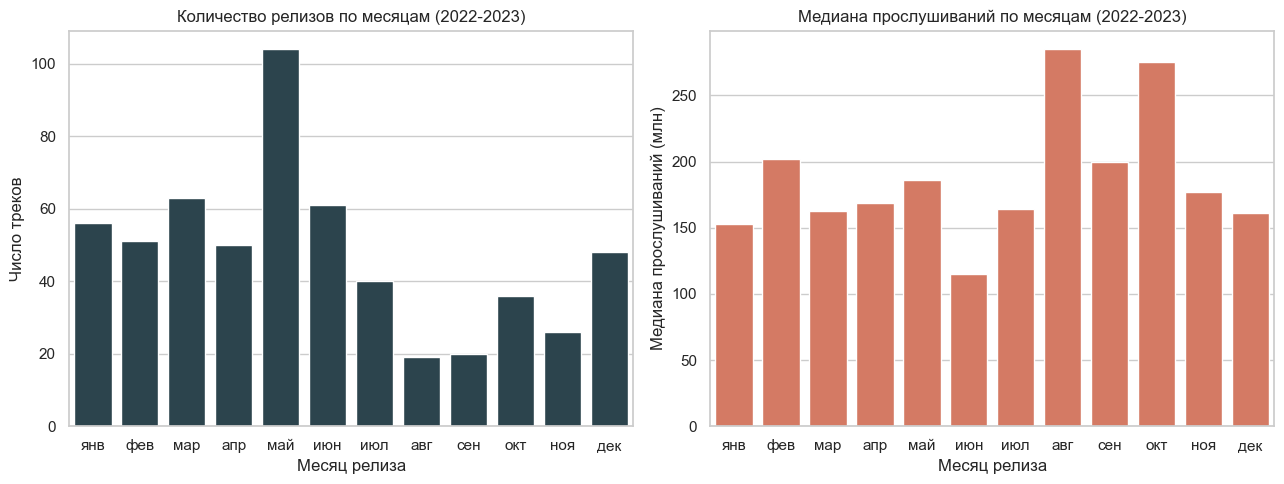

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=by_month.index, y=by_month["releases"], color="#264653", ax=ax1)
ax1.set_title("Количество релизов по месяцам (2022-2023)")
ax1.set_xlabel("Месяц релиза")
ax1.set_ylabel("Число треков")

sns.barplot(x=by_month.index, y=by_month["median_streams"], color="#e76f51", ax=ax2)
ax2.set_title("Медиана прослушиваний по месяцам (2022-2023)")
ax2.set_xlabel("Месяц релиза")
ax2.set_ylabel("Медиана прослушиваний (млн)")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x / 1e6:.0f}")

plt.tight_layout()
plt.show()

**Вывод по Г3.** Сезонность отчётливо видна в *количестве* релизов: пик приходится на май, заметные
всплески - в начале года и в марте. По *стримам* тест Краскела-Уоллиса даёт значимые различия между
месяцами (p < 0.001), но в пользу гипотезы они не играют: месяцы с наибольшим числом релизов (май, март,
январь) дают лишь средние медианы прослушиваний, а самые высокие медианы - у малочисленных августа и
октября (n = 19 и 36), то есть различия держатся на немногих наблюдениях. Гипотеза в исходной формулировке
(«релизы начала года и перед летом набирают больше») не подтверждается: момент выхода связан с тем,
*сколько* треков выпускают, но не гарантирует им больше прослушиваний.

## 6. Гипотеза 4: больше соавторов -> выше шанс попасть в чарты

В качестве меры «попадания в чарты» используем `chart_platforms` - на скольких из четырёх
платформ (Spotify, Apple, Deezer, Shazam) трек попал в чарт. Считаем ранговую корреляцию с
`artist_count` и сравниваем сольные треки с коллаборациями (Манн-Уитни).

In [10]:
rho, rho_p = stats.spearmanr(df["artist_count"], df["chart_platforms"])
print(f"Корреляция Спирмена artist_count vs chart_platforms: rho={rho:.3f}, p-value={rho_p:.3f}")

solo = df.loc[df["artist_count"] == 1, "chart_platforms"]
collab = df.loc[df["artist_count"] > 1, "chart_platforms"]
u_stat, u_p = stats.mannwhitneyu(solo, collab, alternative="two-sided")
print(f"\nСольные (n={len(solo)}): среднее chart_platforms={solo.mean():.2f}")
print(f"Коллабы (n={len(collab)}): среднее chart_platforms={collab.mean():.2f}")
print(f"Манн-Уитни solo vs collab: U={u_stat:,.0f}, p-value={u_p:.3f}")

Корреляция Спирмена artist_count vs chart_platforms: rho=0.024, p-value=0.457

Сольные (n=582): среднее chart_platforms=2.43
Коллабы (n=366): среднее chart_platforms=2.55
Манн-Уитни solo vs collab: U=99,970, p-value=0.101


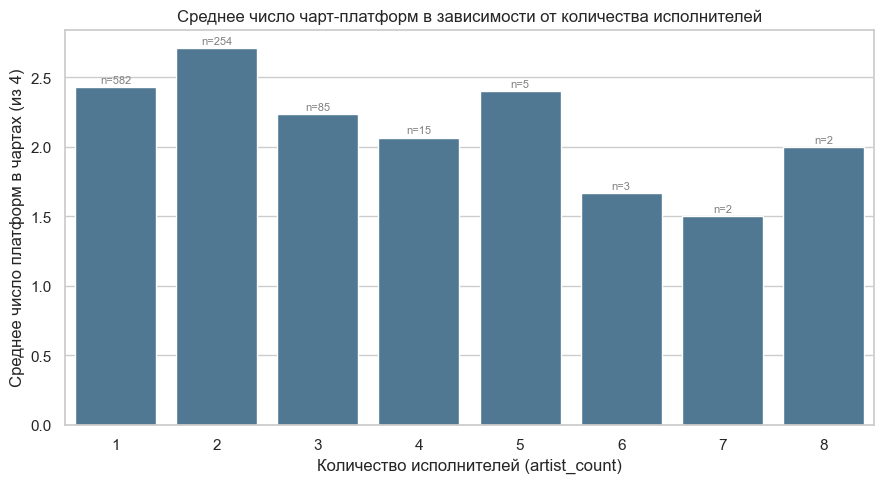

In [11]:
by_artists = df.groupby("artist_count")["chart_platforms"].agg(["mean", "size"])

fig, ax = plt.subplots()
sns.barplot(x=by_artists.index, y=by_artists["mean"], color="#457b9d", ax=ax)
ax.set_title("Среднее число чарт-платформ в зависимости от количества исполнителей")
ax.set_xlabel("Количество исполнителей (artist_count)")
ax.set_ylabel("Среднее число платформ в чартах (из 4)")
for i, (m, n) in enumerate(zip(by_artists["mean"], by_artists["size"])):
    ax.text(i, m + 0.03, f"n={n}", ha="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

**Вывод по Г4.** Корреляция между числом соавторов и попаданием в чарты слабая (см. rho выше).
Гипотеза «больше соавторов = выше шанс в чартах» в явном виде не подтверждается: связь, если и
есть, то очень слабая, а группы с большим artist_count малочисленны (см. n на столбцах).

## 7. Продвинутая часть: тренд и сезонность временного ряда релизов

Гипотеза 3 нащупала сезонность через сравнение месяцев, но это поперечный срез. Здесь строим полноценный **временной ряд** - число релизов по месяцам - и раскладываем его на **тренд + сезонность + остаток** аддитивной декомпозицией (`statsmodels.seasonal_decompose`, период 12 месяцев).

Берём непрерывный участок **2021-01 - 2023-07**: на нём в датасете достаточно треков в каждом месяце, тогда как более ранние годы представлены единичными «выжившими» хитами и ряд там рваный. Важно помнить про смещение выборки: это срез *топ-2023*, поэтому растущий тренд числа релизов отражает не только реальную активность лейблов, но и то, что свежие треки чаще попадают в топ (survivorship bias). Поэтому тренд интерпретируем осторожно, а основной интерес - в **сезонной** компоненте: какие месяцы стабильно выбиваются.

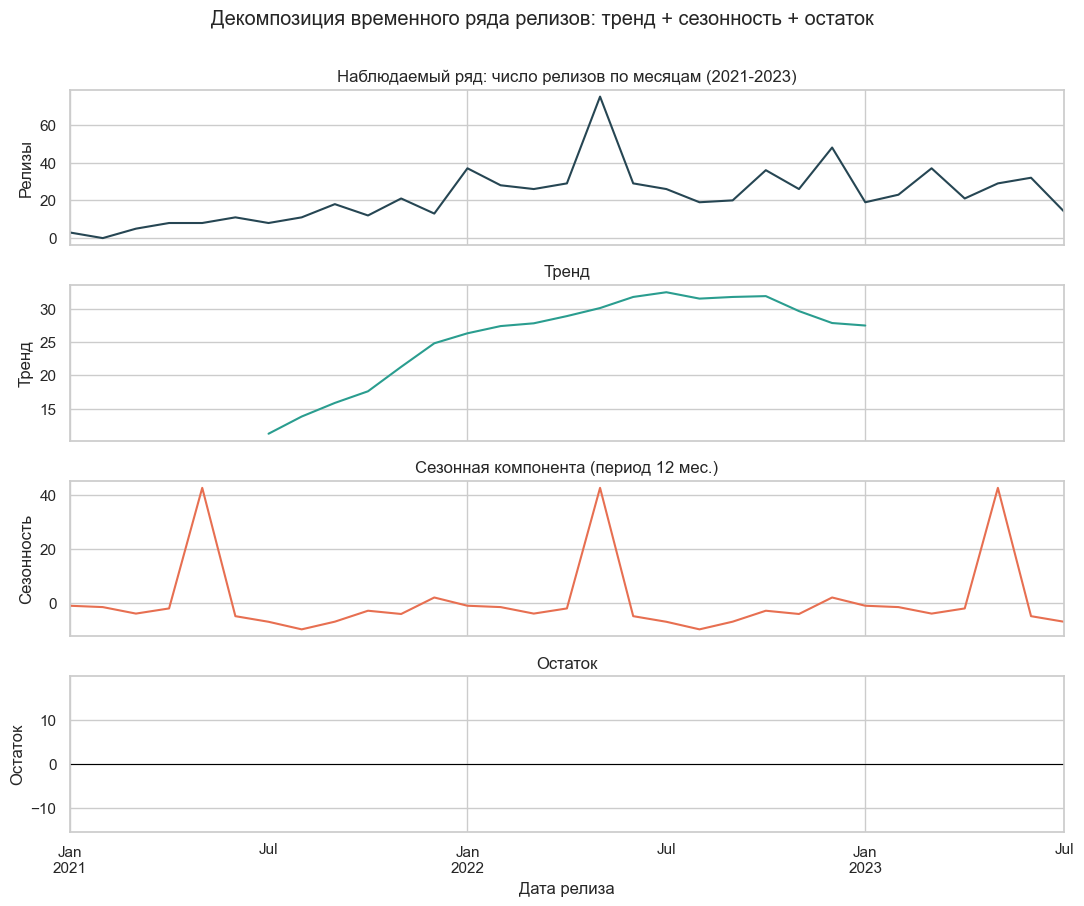

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# непрерывный месячный ряд числа релизов на участке с плотными данными
ts = (
    df.set_index("release_date")
    .resample("MS")
    .size()
    .loc["2021-01":"2023-07"]
    .asfreq("MS")
)
ts.name = "releases"

decomp = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="#264653")
axes[0].set_ylabel("Релизы")
axes[0].set_title("Наблюдаемый ряд: число релизов по месяцам (2021-2023)")
decomp.trend.plot(ax=axes[1], color="#2a9d8f")
axes[1].set_ylabel("Тренд")
axes[1].set_title("Тренд")
decomp.seasonal.plot(ax=axes[2], color="#e76f51")
axes[2].set_ylabel("Сезонность")
axes[2].set_title("Сезонная компонента (период 12 мес.)")
axes[3].plot(decomp.resid.index, decomp.resid.values, color="#9b5de5", marker="o", linestyle="none")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("Остаток")
axes[3].set_title("Остаток")
axes[3].set_xlabel("Дата релиза")
fig.suptitle("Декомпозиция временного ряда релизов: тренд + сезонность + остаток", y=1.005)
plt.tight_layout()
plt.show()

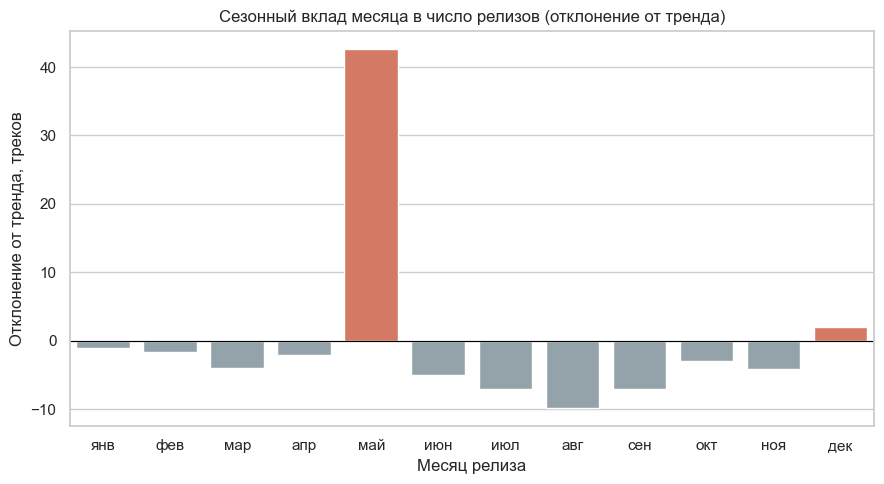

In [17]:
# усреднённый сезонный вклад по календарным месяцам (отклонение от тренда, в треках)
seasonal_by_month = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
seasonal_by_month.index = month_names  # month_names определён в разделе 5

fig, ax = plt.subplots()
colors = ["#e76f51" if v > 0 else "#90a4ae" for v in seasonal_by_month.values]
sns.barplot(x=seasonal_by_month.index, y=seasonal_by_month.values,
            hue=seasonal_by_month.index, palette=colors, legend=False, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Сезонный вклад месяца в число релизов (отклонение от тренда)")
ax.set_xlabel("Месяц релиза")
ax.set_ylabel("Отклонение от тренда, треков")
plt.tight_layout()
plt.show()

**Вывод по временному ряду.** Декомпозиция разделяет три эффекта:

- **Тренд** устойчиво растёт - но, как отмечено выше, это в значительной мере survivorship bias выборки топ-2023, а не чистый рост рынка, поэтому читаем его осторожно.
- **Сезонность** воспроизводит и уточняет вывод Гипотезы 3: сильнее всего вверх выбивается **май**, в плюсе также декабрь; летние месяцы и ранняя весна - в минусе. То есть лейблы из года в год концентрируют релизы на май.
- **Остаток** невелик и без явной структуры: значит тренд и сезонность описывают ряд неплохо, а крупные одиночные всплески (аномально большой май 2022) уходят именно в остаток.

Практический смысл: пик релизной активности - май. Но, как показала Г3, это пик *числа* релизов, а не медианных стримов, так что выпуск «в сезон» сам по себе популярность не гарантирует.

## 8. Итоговые выводы

| Гипотеза | Результат | Кратко |
|---|---|---|
| Г1: мажор стримят больше минора | не подтверждается | разница в стримах между мажором и минором статистически не значима (p > 0.1) |
| Г2: плейлисты важнее звучания | подтверждается | корреляция стримов с числом плейлистов (~0.83) на порядок выше, чем с любой аудио-фичей |
| Г3: сезонность релизов | частично подтверждается | сезонность есть в *числе* релизов (пик — май, подтверждён декомпозицией), но в *стримах* её нет: пик месяца по стримам не совпадает с пиком релизов |
| Г4: больше соавторов -> чарты | не подтверждается | связь artist_count с попаданием в чарты практически нулевая (rho ≈ 0.02) |

**Главный итог.** Что делает трек хитом в этих данных - это в первую очередь попадание в
плейлисты (дистрибуция), а не музыкальные характеристики (тональность, темп, danceability) или
формальные признаки вроде числа соавторов и месяца релиза.

*Точные значения p-value и коэффициентов корреляции - в выводах соответствующих ячеек выше.*